In [1]:
import numpy as np
import matplotlib.pyplot as plt

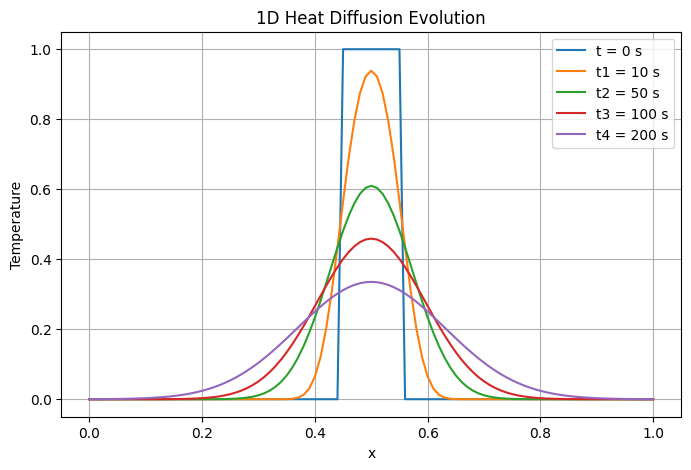

In [15]:
# Heat Transfer in 1D# Parameters

L = 1.0
alpha = 0.01
Nx = 101
dx = L / (Nx - 1)

#Stability condition
dt = 0.4 * dx**2 / alpha  #time step
Nt = 500  #number of time steps

#grid
x = np.linspace(0, L, Nx)

#Initial condition
T = np.zeros(Nx)
T[(x >= 0.45) & (x <= 0.55)] = 1.0

#store for plotting
T_initial = T.copy()
snapshots = [T.copy()]

#Time evolution
for n in range(Nt):
    T_new = T.copy()
    
    for i in range(1, Nx-1):
        T_new[i] = T[i] + alpha * dt / dx**2 * (T[i+1] - 2*T[i] + T[i-1])
    
    #Boundary conditions
    T_new[0] = 0
    T_new[-1] = 0
    
    T = T_new
    
    #Save few snapshots
    if n in [10, 50, 100, 200]:
        snapshots.append(T.copy())

#plots
plt.figure(figsize=(8,5))
plt.plot(x, T_initial, label="t = 0 s")

times = ["t1 = 10 s", "t2 = 50 s", "t3 = 100 s", "t4 = 200 s"]
for i, snap in enumerate(snapshots[1:]):
    plt.plot(x, snap, label=times[i])

plt.xlabel("x")
plt.ylabel("Temperature")
plt.title("1D Heat Diffusion Evolution")
plt.legend()
plt.grid()
plt.show()

**Conclusion (Part 1: Heat Diffusion in 1D & 2D)**

The sharp temperature profile does not remain sharp — it immediately starts smoothing out because heat naturally flows from hot to cold regions. The edges of the hot region spread outward, the peak decreases, and over time the profile becomes wider and flatter until everything cools down due to heat loss at the boundaries.

For numerical stability, the time step must be chosen carefully. If it is too large, the solution becomes unstable and unphysical. Even when stable, the numerical method itself can introduce extra smoothing, which may make the system appear to diffuse faster than it actually should.

In 2D, heat spreads outward in all directions, and ideally the shape should remain symmetric. However, the grid can distort this symmetry slightly, especially at lower resolutions. A finer grid gives results closer to true physical behavior, while a coarse grid increases numerical errors.

Overall, diffusion is inherently a smoothing process, but simulations can exaggerate this effect. So, it is important to check whether the observed smoothing is due to real physics or introduced by the numerical method.


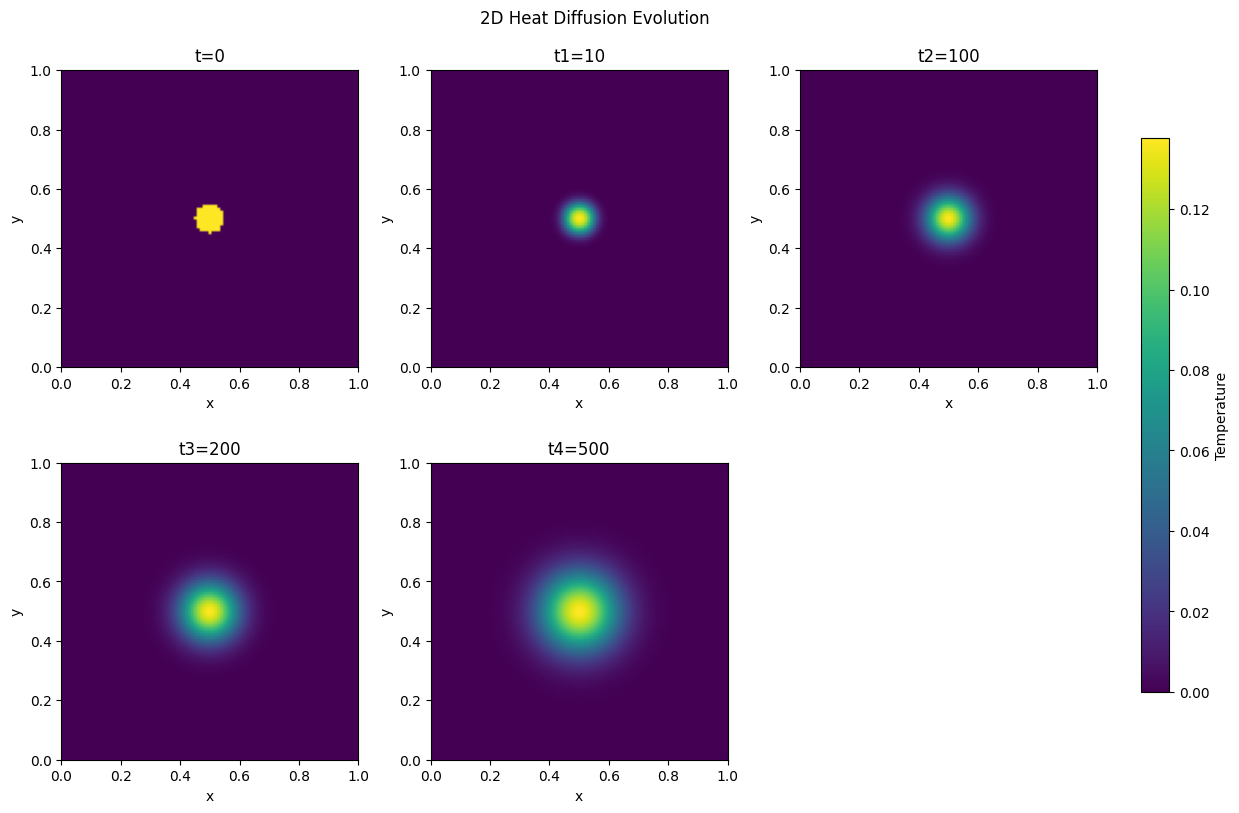

In [27]:
#Parameters
L = 1.0
alpha = 0.01
Nx = Ny = 101

dx = L / (Nx - 1)
dy = dx

#Stability condition (2D)
dt = 0.2 * dx**2 / alpha   # safe choice
Nt = 500

#Grid
x = np.linspace(0, L, Nx)
y = np.linspace(0, L, Ny)

#Temperature field
T = np.zeros((Nx, Ny))

#Initial condition: circular hot region
for i in range(Nx):
    for j in range(Ny):
        if (x[i] - 0.5)**2 + (y[j] - 0.5)**2 < 0.05**2:
            T[i, j] = 1.0

#Store snapshots
snapshots = [T.copy()]

#Time evolution
for n in range(Nt):
    T_new = T.copy()
    
    for i in range(1, Nx-1):
        for j in range(1, Ny-1):
            T_new[i, j] = T[i, j] + alpha * dt * (
                (T[i+1, j] - 2*T[i, j] + T[i-1, j]) / dx**2 +
                (T[i, j+1] - 2*T[i, j] + T[i, j-1]) / dy**2
            )
    
    #Boundary conditions (all edges = 0)
    T_new[0, :] = 0
    T_new[-1, :] = 0
    T_new[:, 0] = 0
    T_new[:, -1] = 0
    
    T = T_new
    
    #Save snapshots
    if n in [10, 50, 100, 200]:
        snapshots.append(T.copy())

#Plotting
fig, ax = plt.subplots(2, 3, figsize=(12, 8))

times = ["t=0", "t1=10", "t2=100", "t3=200", "t4=500"]
ax = ax.flatten()

for k in range(5):
    im = ax[k].imshow(snapshots[k], extent=[0,1,0,1], origin='lower')
    ax[k].set_title(times[k])
    ax[k].set_xlabel("x")
    ax[k].set_ylabel("y")

#Hide extra subplot
ax[5].axis('off')

#Adjust layout BEFORE colorbar
plt.tight_layout()

#Add colorbar on the right side
cbar = fig.colorbar(im, ax=ax[:5], fraction=0.025, pad=0.04)
cbar.set_label("Temperature")

plt.suptitle("2D Heat Diffusion Evolution", y=1.02)
plt.show()

**Conclusion (2D Heat Diffusion)**

In 2D, heat spreads outward in all directions from the central hot region, forming a radially expanding profile. Ideally, the shape remains circular due to symmetry, but in numerical simulations this symmetry is slightly distorted because of the square grid. Compared to 1D, the spreading is faster and the peak decreases more quickly since heat has more directions to flow. Grid resolution plays an important role — finer grids preserve symmetry better, while coarse grids introduce noticeable errors and extra smoothing. Overall, the behavior is still governed by diffusion, but numerical effects become more significant in 2D.


### PART 2: Advection-Diffusion in 2D 

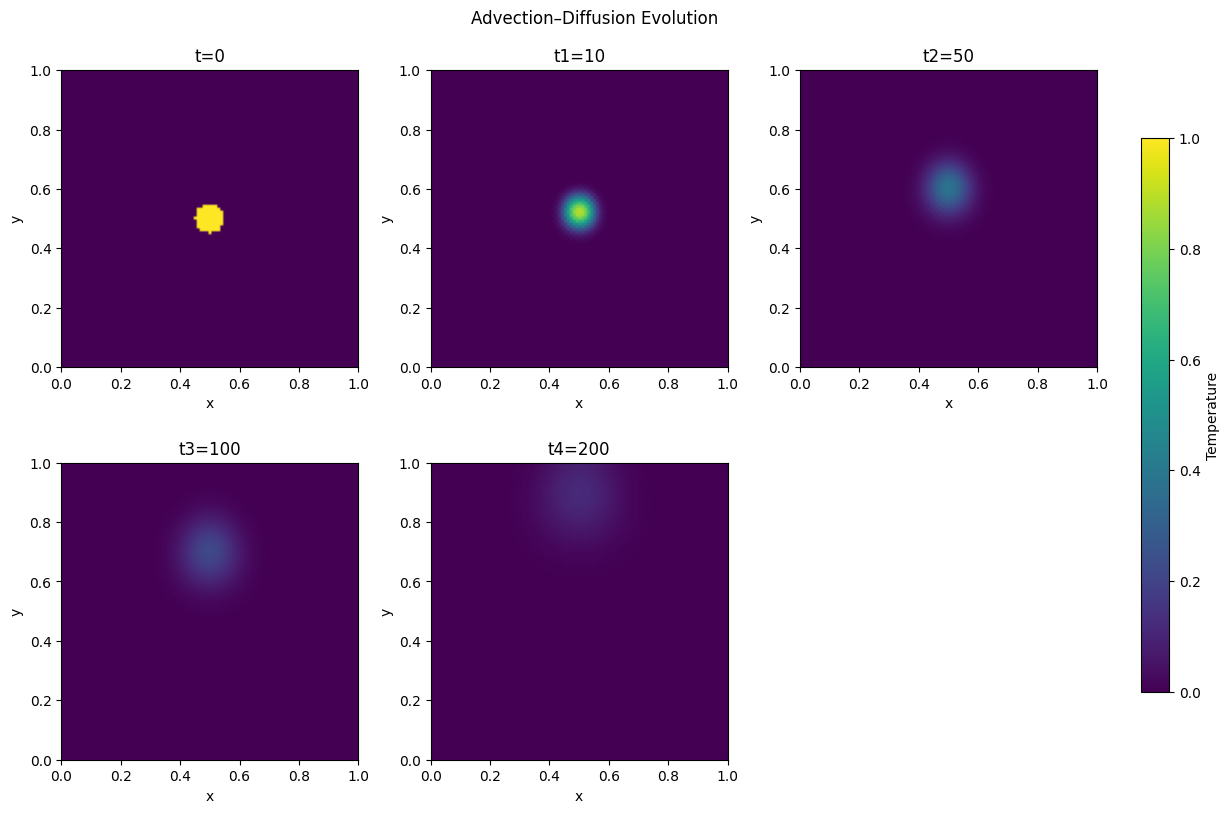

In [33]:
#Parameters
L = 1.0
alpha = 0.01
Umax = 1.0

Nx = Ny = 101
dx = L / (Nx - 1)
dy = dx

#Stability conditions
dt_diff = 0.2 * dx**2 / alpha
dt_adv = 0.5 * dx / Umax
dt = min(dt_diff, dt_adv)

Nt = 500

#Grid
x = np.linspace(0, L, Nx)
y = np.linspace(0, L, Ny)

#Velocity profile u(y)
u = Umax * (1 - (2*y - 1)**2)

#Temperature field
T = np.zeros((Nx, Ny))

#Initial condition: circular hot region
for i in range(Nx):
    for j in range(Ny):
        if (x[i] - 0.5)**2 + (y[j] - 0.5)**2 < 0.05**2:
            T[i, j] = 1.0

#Store snapshots
snapshots = [T.copy()]

#Time evolution
for n in range(Nt):
    T_new = T.copy()
    
    for i in range(1, Nx-1):
        for j in range(1, Ny-1):
            
            # --- Advection term (Upwind scheme) ---
            adv = u[j] * (T[i, j] - T[i-1, j]) / dx
            
            # --- Diffusion term ---
            diff = alpha * (
                (T[i+1, j] - 2*T[i, j] + T[i-1, j]) / dx**2 +
                (T[i, j+1] - 2*T[i, j] + T[i, j-1]) / dy**2
            )
            
            # Update equation
            T_new[i, j] = T[i, j] - dt * adv + dt * diff

    #Boundary conditions
    
    #Inlet (x = 0)
    T_new[0, :] = 0
    
    #Outlet (x = L) → zero gradient
    T_new[-1, :] = T_new[-2, :]
    
    #Walls (y = 0, 1) → insulated
    T_new[:, 0] = T_new[:, 1]
    T_new[:, -1] = T_new[:, -2]

    T = T_new

    #Save snapshots
    if n in [10, 50, 100, 200]:
        snapshots.append(T.copy())

#Plotting
fig, ax = plt.subplots(2, 3, figsize=(12, 8))
ax = ax.flatten()

times = ["t=0", "t1=10", "t2=50", "t3=100", "t4=200"]

for k in range(5):
    im = ax[k].imshow(
        snapshots[k],
        extent=[0,1,0,1],
        origin='lower',
        cmap='viridis',
        vmin=0,
        vmax=1
    )
    ax[k].set_title(times[k])
    ax[k].set_xlabel("x")
    ax[k].set_ylabel("y")

ax[5].axis('off')

plt.tight_layout()
cbar = fig.colorbar(im, ax=ax[:5], fraction=0.025, pad=0.04)
cbar.set_label("Temperature")

plt.suptitle("Advection–Diffusion Evolution", y=1.02)
plt.show()

**Conclusion (Advection–Diffusion)**

When flow is introduced, the heat no longer just spreads — it is also transported downstream. The hot region moves in the direction of flow, while simultaneously spreading due to diffusion. Because the velocity varies across the channel, different أجزاء of the hot region move at different speeds, causing the profile to stretch and deform. Diffusion continues to smooth the profile, making it broader and less sharp over time.

Handling the advection term requires careful numerical treatment. A central difference scheme can produce non-physical oscillations, so an upwind scheme is preferred for stability. However, the upwind method introduces additional numerical diffusion, which can exaggerate the smoothing of the temperature profile.

Overall, the observed behavior is a combination of transport and spreading, but care must be taken to distinguish real physical diffusion from artificial numerical effects introduced by the discretization.
